# Notebook 10 — Front Trajectory Cleaning

## Mục tiêu
Chuẩn hóa và làm sạch quỹ đạo từ tracker đã chọn trước khi trích xuất đặc trưng hành vi.

Luồng:
`raw video → YOLO → ByteTrack B15 → raw tracks → trajectory cleaning → cleaned trajectories`

## Nguyên tắc
- `pred_track_id` là **Track ID**, không mặc định là biological identity.
- Không nối hai quỹ đạo qua khoảng mất dấu dài.
- Chỉ nội suy các gap rất ngắn.
- Làm mượt nhằm giảm jitter bbox, không được làm thay đổi chuyển động lớn thực sự.
- Notebook này không gán nhãn hành vi.
- Nếu full-video raw tracking CSV chưa có, cell 2 có tùy chọn tạo bằng ByteTrack B15. Mặc định **không tự chạy**.

In [1]:
# ============================================================
# 0. SETUP
# ============================================================
from pathlib import Path
import hashlib, json, math, subprocess, sys, time
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

def find_project_root():
    candidates = [
        Path("/home/diy-hus/fish"),
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
    ]
    for p in candidates:
        if (p / "data").exists() and (p / "notebooks").exists():
            return p.resolve()
    return Path("/home/diy-hus/fish").resolve()

PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / "results/trajectory"
LOG_DIR = PROJECT_ROOT / "logs/trajectory/FRONT_TRAJECTORY_CLEANING_001"
RAW_TRACK_DIR = PROJECT_ROOT / "outputs/front/full_tracks"
for p in [RESULTS_DIR, LOG_DIR, RAW_TRACK_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Python:", sys.version.split()[0])
print("OpenCV:", cv2.__version__)
print("pandas:", pd.__version__)

PROJECT_ROOT: /home/diy-hus/fish
Python: 3.11.15
OpenCV: 4.10.0
pandas: 3.0.5


In [ ]:
# ============================================================
# 1. CONFIG
# ============================================================
EXPERIMENT_ID = "FRONT_TRAJECTORY_CLEANING_001"

VIDEO_REGISTRY = {
    "V4_BREEDING": {"filename": "4.mp4", "context": "BREEDING_PARENTAL_CARE"},
    "V8_PAIR_T1": {"filename": "8.mp4", "context": "PAIR_T1"},
    "V5_NORMAL": {"filename": "5.mp4", "context": "NORMAL"},
    "V3_FEEDING": {"filename": "3.mp4", "context": "FEEDING"},
}

SELECTED_TRACKER = "BYTE_B15"
MODEL_PATH = PROJECT_ROOT / "runs/front/yolov8n_front_v1_baseline/weights/best.pt"
TRACKER_YAML = PROJECT_ROOT / "configs/trackers/front_bytetrack_b15.yaml"

DETECTION_FLOOR = 0.50
IMGSZ = 640
DEVICE = 0

# Chỉ đổi True nếu full-video track CSV chưa có.
GENERATE_MISSING_RAW_TRACKS = False

# Cleaning
MAX_INTERP_GAP_FRAMES = 3
SMOOTH_WINDOW_FRAMES = 5       # rolling median, nên là số lẻ
MIN_SEGMENT_POINTS = 5

RAW_TRACK_CSVS = {
    video_id: RAW_TRACK_DIR / f"{video_id}_{SELECTED_TRACKER}_tracks.csv"
    for video_id in VIDEO_REGISTRY
}

CLEANED_TRAJECTORY_PATH = RESULTS_DIR / "front_cleaned_trajectories.csv"
QC_PATH = RESULTS_DIR / "front_trajectory_cleaning_qc.csv"

print("Tracker:", SELECTED_TRACKER)
print("MAX_INTERP_GAP_FRAMES:", MAX_INTERP_GAP_FRAMES)
print("SMOOTH_WINDOW_FRAMES:", SMOOTH_WINDOW_FRAMES)

Tracker: BYTE_B15
MAX_INTERP_GAP_FRAMES: 3
SMOOTH_WINDOW_FRAMES: 5


In [6]:
# ============================================================
# 2. OPTIONAL — MATERIALIZE FULL-VIDEO RAW TRACKS
# Mặc định không chạy.
# ============================================================
def _video_meta(path):
    cap = cv2.VideoCapture(str(path))
    meta = {
        "fps": float(cap.get(cv2.CAP_PROP_FPS)),
        "frame_count": int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
        "width": int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        "height": int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    }
    cap.release()
    return meta

def _generate_full_tracks(video_id, out_csv):
    from ultralytics import YOLO

    cfg = VIDEO_REGISTRY[video_id]
    video_path = PROJECT_ROOT / "data/raw/front" / cfg["filename"]
    assert video_path.is_file(), video_path
    assert MODEL_PATH.is_file(), MODEL_PATH
    assert TRACKER_YAML.is_file(), TRACKER_YAML

    meta = _video_meta(video_path)
    model = YOLO(str(MODEL_PATH))
    cap = cv2.VideoCapture(str(video_path))
    rows = []
    t0 = time.perf_counter()

    for fi in range(meta["frame_count"]):
        ok, frame = cap.read()
        if not ok:
            break
        result = model.track(
            frame,
            persist=True,
            tracker=str(TRACKER_YAML),
            conf=DETECTION_FLOOR,
            imgsz=IMGSZ,
            device=DEVICE,
            verbose=False,
        )[0]

        boxes = result.boxes
        if boxes is None or boxes.id is None:
            continue

        xyxy = boxes.xyxy.detach().cpu().numpy()
        ids = boxes.id.detach().cpu().numpy().astype(int)
        conf = boxes.conf.detach().cpu().numpy()
        cls = boxes.cls.detach().cpu().numpy().astype(int)

        for box, tid, cf, cl in zip(xyxy, ids, conf, cls):
            x1, y1, x2, y2 = map(float, box)
            rows.append({
                "tracker": SELECTED_TRACKER,
                "video_id": video_id,
                "frame_index": fi,
                "time_sec": fi / meta["fps"],
                "pred_track_id": int(tid),
                "class_id": int(cl),
                "confidence": float(cf),
                "x1": x1, "y1": y1, "x2": x2, "y2": y2,
                "fps_source": meta["fps"],
                "frame_width": meta["width"],
                "frame_height": meta["height"],
            })

    cap.release()
    pd.DataFrame(rows).to_csv(out_csv, index=False)
    elapsed = time.perf_counter() - t0
    print(video_id, "rows:", len(rows), "processing FPS:", meta["frame_count"]/elapsed if elapsed else np.nan)

missing = [v for v, p in RAW_TRACK_CSVS.items() if not p.exists()]
print("Missing raw-track CSVs:", missing)

if GENERATE_MISSING_RAW_TRACKS:
    for video_id in missing:
        _generate_full_tracks(video_id, RAW_TRACK_CSVS[video_id])
else:
    if missing:
        print("USER_ACTION_REQUIRED_FULL_TRACKS")
        print("Nếu muốn Notebook 10 tạo các CSV còn thiếu, đổi GENERATE_MISSING_RAW_TRACKS=True rồi chạy lại cell này.")

Missing raw-track CSVs: ['V4_BREEDING', 'V8_PAIR_T1', 'V5_NORMAL', 'V3_FEEDING']
V4_BREEDING rows: 2380 processing FPS: 90.07389395530178
V8_PAIR_T1 rows: 1689 processing FPS: 91.15619632141133
V5_NORMAL rows: 16508 processing FPS: 81.323525132363
V3_FEEDING rows: 20258 processing FPS: 81.0238035498284


In [7]:
# ============================================================
# 3. LOAD + NORMALIZE RAW TRACKS
# ============================================================
required = [
    "video_id","frame_index","time_sec","pred_track_id",
    "x1","y1","x2","y2"
]
tables = []

for video_id, path in RAW_TRACK_CSVS.items():
    if not path.exists():
        continue

    df = pd.read_csv(path)
    missing_cols = [c for c in required if c not in df.columns]
    if missing_cols:
        raise ValueError(f"{path}: missing columns {missing_cols}")

    meta = _video_meta(PROJECT_ROOT / "data/raw/front" / VIDEO_REGISTRY[video_id]["filename"])

    if "fps_source" not in df:
        df["fps_source"] = meta["fps"]
    if "frame_width" not in df:
        df["frame_width"] = meta["width"]
    if "frame_height" not in df:
        df["frame_height"] = meta["height"]
    if "confidence" not in df:
        df["confidence"] = np.nan

    df["video_id"] = video_id
    df["context"] = VIDEO_REGISTRY[video_id]["context"]
    df["cx_raw"] = (df["x1"] + df["x2"]) / 2.0
    df["cy_raw"] = (df["y1"] + df["y2"]) / 2.0
    df["bbox_w"] = df["x2"] - df["x1"]
    df["bbox_h"] = df["y2"] - df["y1"]
    df["bbox_area"] = df["bbox_w"] * df["bbox_h"]
    tables.append(df)

if not tables:
    raise RuntimeError("NO_RAW_TRACK_INPUTS — hoàn thiện cell 2 trước.")

RAW = pd.concat(tables, ignore_index=True)
RAW = RAW.sort_values(["video_id","pred_track_id","frame_index"]).reset_index(drop=True)

print("Raw rows:", len(RAW))
print("Videos:", RAW["video_id"].value_counts().to_dict())
print("Unique tracker IDs:", RAW.groupby("video_id")["pred_track_id"].nunique().to_dict())

Raw rows: 40835
Videos: {'V3_FEEDING': 20258, 'V5_NORMAL': 16508, 'V4_BREEDING': 2380, 'V8_PAIR_T1': 1689}
Unique tracker IDs: {'V3_FEEDING': 121, 'V4_BREEDING': 2, 'V5_NORMAL': 77, 'V8_PAIR_T1': 14}


In [8]:
# ============================================================
# 4. SPLIT LONG GAPS + SHORT-GAP INTERPOLATION + SMOOTHING
# ============================================================
def clean_one_track(track):
    track = track.sort_values("frame_index").copy()
    frame_diff = track["frame_index"].diff().fillna(1)

    # Gap > MAX_INTERP_GAP_FRAMES + 1 => new trajectory segment.
    new_segment = frame_diff > (MAX_INTERP_GAP_FRAMES + 1)
    track["segment_no"] = new_segment.cumsum().astype(int)

    cleaned_parts = []

    for seg_no, seg in track.groupby("segment_no", sort=True):
        seg = seg.sort_values("frame_index").copy()
        if len(seg) < MIN_SEGMENT_POINTS:
            continue

        full_frames = np.arange(int(seg["frame_index"].min()), int(seg["frame_index"].max()) + 1)
        base = pd.DataFrame({"frame_index": full_frames})
        base = base.merge(seg, on="frame_index", how="left", suffixes=("", "_orig"))

        observed = base["pred_track_id"].notna()

        # Constant metadata
        for col in ["video_id","context","fps_source","frame_width","frame_height"]:
            base[col] = base[col].ffill().bfill()
        base["pred_track_id"] = base["pred_track_id"].ffill().bfill().astype(int)

        # Derive exact time from frame/fps to avoid interpolation drift
        base["time_sec"] = base["frame_index"] / base["fps_source"]

        # Only gaps inside this short-gap segment are eligible.
        for col in ["x1","y1","x2","y2","cx_raw","cy_raw","bbox_w","bbox_h","bbox_area","confidence"]:
            base[col] = pd.to_numeric(base[col], errors="coerce")
            base[col] = base[col].interpolate(limit=MAX_INTERP_GAP_FRAMES, limit_area="inside")

        base["observed"] = observed
        base["interpolated"] = ~observed & base["cx_raw"].notna()

        # Drop any row that could not be safely interpolated.
        base = base[base["cx_raw"].notna() & base["cy_raw"].notna()].copy()

        # Robust median smoothing.
        w = min(SMOOTH_WINDOW_FRAMES, len(base))
        if w % 2 == 0:
            w = max(1, w - 1)
        base["cx_clean"] = base["cx_raw"].rolling(w, center=True, min_periods=1).median()
        base["cy_clean"] = base["cy_raw"].rolling(w, center=True, min_periods=1).median()

        # Normalized coordinates [0,1]
        base["x_norm"] = base["cx_clean"] / base["frame_width"]
        base["y_norm"] = base["cy_clean"] / base["frame_height"]

        video_id = str(base["video_id"].iloc[0])
        tid = int(base["pred_track_id"].iloc[0])
        base["trajectory_segment_id"] = int(seg_no)
        base["trajectory_uid"] = (
            video_id + ":T" + str(tid) + ":S" + str(int(seg_no))
        )

        cleaned_parts.append(base)

    return cleaned_parts

parts = []
for (_, _), track in RAW.groupby(["video_id","pred_track_id"], sort=False):
    parts.extend(clean_one_track(track))

if not parts:
    raise RuntimeError("NO_CLEANED_TRAJECTORIES")

CLEAN = pd.concat(parts, ignore_index=True)
CLEAN = CLEAN.sort_values(["video_id","pred_track_id","trajectory_segment_id","frame_index"]).reset_index(drop=True)

keep_cols = [
    "video_id","context","frame_index","time_sec","pred_track_id",
    "trajectory_segment_id","trajectory_uid",
    "x1","y1","x2","y2","bbox_w","bbox_h","bbox_area","confidence",
    "cx_raw","cy_raw","cx_clean","cy_clean","x_norm","y_norm",
    "observed","interpolated","fps_source","frame_width","frame_height",
]
CLEAN[keep_cols].to_csv(CLEANED_TRAJECTORY_PATH, index=False)

print("Cleaned rows:", len(CLEAN))
print("Trajectory segments:", CLEAN["trajectory_uid"].nunique())
print("Saved:", CLEANED_TRAJECTORY_PATH)

Cleaned rows: 40845
Trajectory segments: 286
Saved: /home/diy-hus/fish/results/trajectory/front_cleaned_trajectories.csv


In [9]:
# ============================================================
# 5. QC — BEFORE / AFTER CLEANING
# ============================================================
qc_rows = []

for uid, sub in CLEAN.groupby("trajectory_uid"):
    sub = sub.sort_values("frame_index")
    raw_step = np.hypot(sub["cx_raw"].diff(), sub["cy_raw"].diff())
    clean_step = np.hypot(sub["cx_clean"].diff(), sub["cy_clean"].diff())

    qc_rows.append({
        "trajectory_uid": uid,
        "video_id": sub["video_id"].iloc[0],
        "pred_track_id": int(sub["pred_track_id"].iloc[0]),
        "trajectory_segment_id": int(sub["trajectory_segment_id"].iloc[0]),
        "points": len(sub),
        "observed_points": int(sub["observed"].sum()),
        "interpolated_points": int(sub["interpolated"].sum()),
        "duration_sec": float(sub["time_sec"].max() - sub["time_sec"].min()),
        "mean_raw_step_px": float(raw_step.dropna().mean()) if raw_step.notna().any() else np.nan,
        "mean_clean_step_px": float(clean_step.dropna().mean()) if clean_step.notna().any() else np.nan,
        "max_clean_step_px": float(clean_step.dropna().max()) if clean_step.notna().any() else np.nan,
    })

QC = pd.DataFrame(qc_rows)
QC.to_csv(QC_PATH, index=False)
display(QC.head(20))

print("QC rows:", len(QC))
print("Interpolated total:", int(CLEAN["interpolated"].sum()))
print("Saved:", QC_PATH)

,trajectory_uid,video_id,pred_track_id,trajectory_segment_id,points,observed_points,interpolated_points,duration_sec,mean_raw_step_px,mean_clean_step_px,max_clean_step_px
0,V3_FEEDING:T101:S0,V3_FEEDING,101,0,22,22,0,0.738345,1.928687,1.099067,2.528717
1,V3_FEEDING:T101:S1,V3_FEEDING,101,1,26,26,0,0.878982,1.899257,1.225495,3.933472
2,V3_FEEDING:T102:S0,V3_FEEDING,102,0,293,293,0,10.266505,4.474653,4.191791,21.989729
3,V3_FEEDING:T102:S1,V3_FEEDING,102,1,32,31,1,1.089937,7.091376,3.886636,20.455752
4,V3_FEEDING:T103:S0,V3_FEEDING,103,0,140,140,0,4.887138,3.696838,3.147099,14.807591
5,V3_FEEDING:T104:S0,V3_FEEDING,104,0,144,144,0,5.027775,1.927361,1.529982,6.807391
6,V3_FEEDING:T105:S0,V3_FEEDING,105,0,110,110,0,3.832360,3.832404,2.975487,13.514357
7,V3_FEEDING:T107:S0,V3_FEEDING,107,0,207,207,0,7.242808,5.233900,4.884035,17.130543
8,V3_FEEDING:T112:S0,V3_FEEDING,112,0,9,9,0,0.281274,5.608582,3.552030,5.057624
9,V3_FEEDING:T112:S1,V3_FEEDING,112,1,29,29,0,0.984459,2.529170,2.006714,4.345787


QC rows: 286
Interpolated total: 74
Saved: /home/diy-hus/fish/results/trajectory/front_trajectory_cleaning_qc.csv


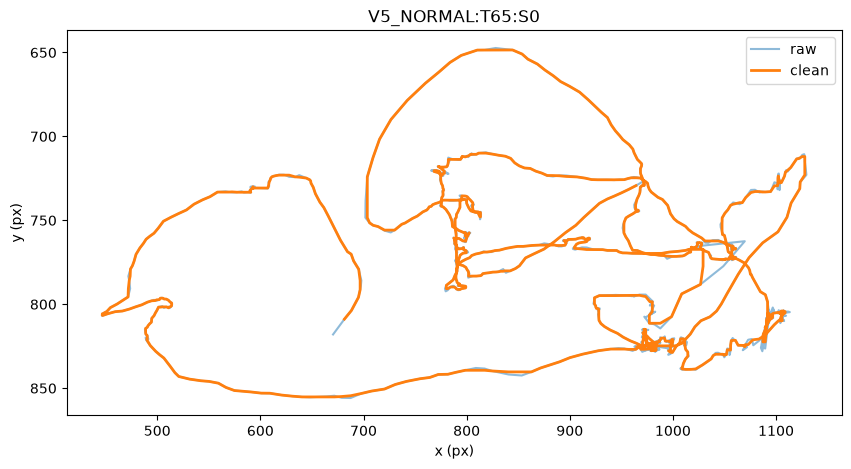

In [10]:
# ============================================================
# 6. OPTIONAL VISUAL QC
# ============================================================
EXAMPLE_UID = CLEAN["trajectory_uid"].value_counts().index[0]
ex = CLEAN[CLEAN["trajectory_uid"].eq(EXAMPLE_UID)].sort_values("frame_index")

plt.figure(figsize=(10,5))
plt.plot(ex["cx_raw"], ex["cy_raw"], alpha=0.5, label="raw")
plt.plot(ex["cx_clean"], ex["cy_clean"], linewidth=2, label="clean")
plt.gca().invert_yaxis()
plt.xlabel("x (px)")
plt.ylabel("y (px)")
plt.title(EXAMPLE_UID)
plt.legend()
plt.show()

In [11]:
# ============================================================
# 7. FINAL SUMMARY
# ============================================================
summary = {
    "experiment_id": EXPERIMENT_ID,
    "selected_tracker": SELECTED_TRACKER,
    "max_interp_gap_frames": MAX_INTERP_GAP_FRAMES,
    "smooth_window_frames": SMOOTH_WINDOW_FRAMES,
    "cleaned_rows": int(len(CLEAN)),
    "trajectory_segments": int(CLEAN["trajectory_uid"].nunique()),
    "interpolated_rows": int(CLEAN["interpolated"].sum()),
    "outputs": [
        str(CLEANED_TRAJECTORY_PATH.relative_to(PROJECT_ROOT)),
        str(QC_PATH.relative_to(PROJECT_ROOT)),
    ],
}
(LOG_DIR / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
print("FINAL SUMMARY")
print(json.dumps(summary, indent=2))

FINAL SUMMARY
{
  "experiment_id": "FRONT_TRAJECTORY_CLEANING_001",
  "selected_tracker": "BYTE_B15",
  "max_interp_gap_frames": 3,
  "smooth_window_frames": 5,
  "cleaned_rows": 40845,
  "trajectory_segments": 286,
  "interpolated_rows": 74,
  "outputs": [
    "results/trajectory/front_cleaned_trajectories.csv",
    "results/trajectory/front_trajectory_cleaning_qc.csv"
  ]
}
